### 1. Imports & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 2. Configuration

In [2]:
DATA_DIR = '/Users/rose/Documents/Projects/CNN Skin Disease/dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

BATCH_SIZE    = 64     
NUM_EPOCHS    = 50      
LEARNING_RATE = 0.0001
NUM_CLASSES   = 23
IMG_SIZE      = 224

### 3. Data Loading

In [3]:
# Augmented transforms - adds augmentation to training only
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5414, 0.4142, 0.3823],
                         std=[0.1929, 0.1663, 0.1607])
])

# No augmentation on test/val — only normalize
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5414, 0.4142, 0.3823],
                         std=[0.1929, 0.1663, 0.1607])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

# Val split
from torch.utils.data import random_split
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training images : {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images     : {len(test_dataset)}")
print(f"Classes ({NUM_CLASSES}): {train_dataset.classes}")

Training images : 12446
Validation images: 3111
Test images     : 4002
Classes (23): ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


### 4. CNN Model

In [4]:
from torch.utils.data import random_split
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
class DropoutCNN(nn.Module):
    def __init__(self, num_classes=23):
        super(DropoutCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 224x224 → 112x112
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 112x112 → 56x56
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 56x56 → 28x28
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 → 14x14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),  # fixed from 4*4
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = DropoutCNN(num_classes=NUM_CLASSES).to(device)
print(model)

DropoutCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

### 5. Loss & Optimizer

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels = [train_dataset.targets[i] for i in range(len(train_dataset))]
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(NUM_CLASSES), y=labels)

In [7]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

### 6. Training Loop

In [8]:
best_val_acc = 0.0
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    # --- Checkpoint best model ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_dropout.pth')
        print(f"  ✓ Saved best model")

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Val Acc={val_acc:.4f}")

Epoch 1/50: 100%|██████████| 195/195 [03:36<00:00,  1.11s/it]


  ✓ Saved best model
Epoch 1: Train Loss=3.1418 Train Acc=0.0619 | Val Loss=3.0469 Val Acc=0.0897


Epoch 2/50: 100%|██████████| 195/195 [03:48<00:00,  1.17s/it]


  ✓ Saved best model
Epoch 2: Train Loss=3.0485 Train Acc=0.0859 | Val Loss=2.9619 Val Acc=0.1048


Epoch 3/50: 100%|██████████| 195/195 [03:40<00:00,  1.13s/it]


...

Epoch 48: Train Loss=2.4865 Train Acc=0.2189 | Val Loss=2.5756 Val Acc=0.2311


Epoch 49/50: 100%|██████████| 195/195 [03:33<00:00,  1.10s/it]


Epoch 49: Train Loss=2.4890 Train Acc=0.2137 | Val Loss=2.5577 Val Acc=0.2330


Epoch 50/50: 100%|██████████| 195/195 [03:34<00:00,  1.10s/it]


  ✓ Saved best model
Epoch 50: Train Loss=2.4692 Train Acc=0.2205 | Val Loss=2.5376 Val Acc=0.2578


### 7. Evaluation

In [9]:
model.load_state_dict(torch.load('best_dropout.pth'))

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== TEST RESULTS ===")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score  : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds, average='weighted'):.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Evaluating: 100%|██████████| 63/63 [00:30<00:00,  2.04it/s]


=== TEST RESULTS ===
Accuracy  : 0.2644
F1 Score  : 0.2511
Precision : 0.2921
Recall    : 0.2644

Full Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.36      0.53      0.43       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.33      0.42      0.37       288
                                          Atopic Dermatitis Photos       0.15      0.24      0.18       123
                                            Bullous Disease Photos       0.06      0.04      0.05       113
                Cellulitis Impetigo and other Bacterial Infections       0.08      0.12      0.10        73
                                                     Eczema Photos       0.30      0.23      0.26       309
                                      Exanthems and Drug Eruptions       0.19      0.30      0.23       101
                 Hair L

### 8. Plot Training Curves

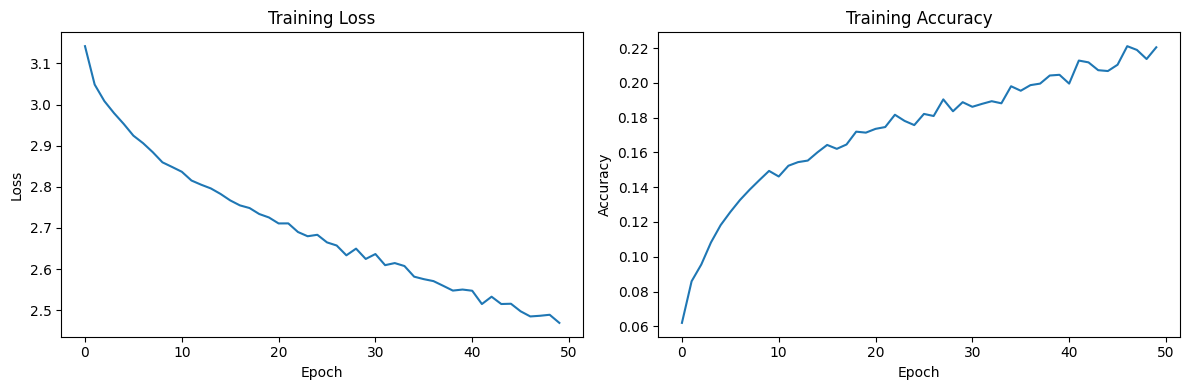

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(train_accuracies)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.savefig('basic_cnn_training.png')
plt.show()